# Matplotlib 5 – Boxplot, Streudiagramm und Diagramm-Tricks
### Unterrichtsmaterial | Julia Brutskaya | FIDP / Daten- und Prozessanalyse

Heute Vormittag hast du Boxplots und Streudiagramme von Hand gezeichnet und Herrn Bauchgefühls Diagramm-Tricks entlarvt. Jetzt baust du alles mit Matplotlib nach, und dazu das Liniendiagramm und das Raster aus mehreren Diagrammen.

| Block | Thema |
|---|---|
| A | Der Boxplot |
| B | Raster und Gruppen |
| C | Das Streudiagramm |
| D | Liniendiagramm und Diagramm-Tricks |
| E | Welches Diagramm wann? |
| F | Weitere Übungen |

---

## Vorbereitung

Die Kurs-Umfrage hat zwei neue Spalten: `lernstunden` (Lernstunden pro Woche zu Hause) und `punkte` (Punkte in der Zwischenprüfung). Morgen brauchst du sie wieder.

`cbook` ist ein Hilfsmodul von Matplotlib. Damit liest du gleich aus, welche Zahlen ein Boxplot zeichnet.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cbook

zeilen = [
    # teilnehmer_id, kurszeit, getraenk, tshirt, haustiere, anfahrt_min, lernstunden, punkte
    (101, "Vormittag", "Kaffee", "M", 0, 25, 3, 50), (102, "Abend", "Tee", "S", 1, 35, 4, 58),
    (103, "Vormittag", "Mate", "L", 0, 18, 4, 63), (104, "Vormittag", "Kaffee", "L", 2, 42, 9, 81),
    (105, "Abend", "Wasser", "M", 0, 30, 8, 84), (106, "Vormittag", "Tee", "M", 1, 28, 5, 60),
    (107, "Abend", "Kaffee", "XL", 0, 55, 9, 86), (108, "Vormittag", "Kaffee", "S", 3, 12, 7, 79),
    (109, "Vormittag", "Mate", "M", 1, 38, 3, 57), (110, "Abend", "Tee", "M", 0, 115, 12, 66),
    (111, "Vormittag", "Kaffee", "L", 0, 32, 10, 88), (112, "Abend", "Mate", "L", 2, 45, 1, 47),
    (113, "Vormittag", "Wasser", "S", 1, 22, 6, 72), (114, "Vormittag", "Kaffee", "M", 0, 35, 5, 62),
    (115, "Abend", "Tee", "L", 1, 48, 11, 94), (116, "Vormittag", "Tee", "M", 0, 30, 8, 76),
    (117, "Abend", "Kaffee", "M", 3, 65, 2, 52), (118, "Vormittag", "Mate", "XL", 1, 40, 6, 69),
    (119, "Abend", "Wasser", "S", 0, 52, 7, 70), (120, "Vormittag", "Kaffee", "L", 2, 25, 6, 61),
]
spalten = ["teilnehmer_id", "kurszeit", "getraenk", "tshirt", "haustiere", "anfahrt_min", "lernstunden", "punkte"]
umfrage = pd.DataFrame(zeilen, columns=spalten)
umfrage["tshirt"] = pd.Categorical(umfrage["tshirt"], categories=["S", "M", "L", "XL"], ordered=True)
anfahrt = umfrage["anfahrt_min"]

# Farben wie im Skript
BLAU, ORANGE = "#2a78d6", "#eb6834"
GETRAENK_FARBEN = {"Kaffee": "#2a78d6", "Tee": "#eb6834", "Mate": "#1baf7a", "Wasser": "#eda100"}

umfrage.head()

,teilnehmer_id,kurszeit,getraenk,tshirt,haustiere,anfahrt_min,lernstunden,punkte
0,101,Vormittag,Kaffee,M,0,25,3,50
1,102,Abend,Tee,S,1,35,4,58
2,103,Vormittag,Mate,L,0,18,4,63
3,104,Vormittag,Kaffee,L,2,42,9,81
4,105,Abend,Wasser,M,0,30,8,84


# Block A – Der Boxplot

## 1 – Fünf Zahlen als Bild
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Fünf Zahlen liest doch keiner. Gebt mir ein Bild.“</td></tr></table>

Ausnahmsweise hat er recht. Genau dafür gibt es den Boxplot. `ax.boxplot()` bekommt die **Rohdaten** und rechnet alles selbst aus.

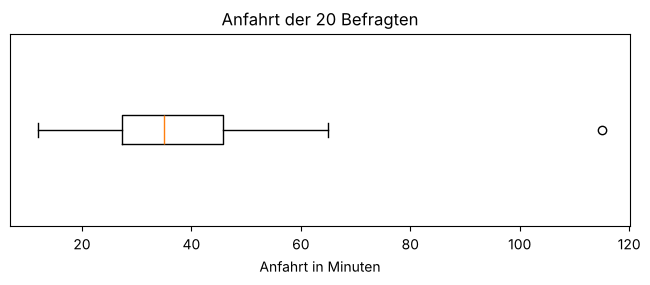

In [2]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.boxplot(anfahrt, orientation="horizontal")
ax.set_title("Anfahrt der 20 Befragten")
ax.set_xlabel("Anfahrt in Minuten")
ax.set_yticks([])                                     # links steht nur eine 1, die brauchen wir nicht
plt.show()

| Teil | Bedeutung |
|---|---|
| Box | von Q1 bis Q3, darin liegen die mittleren 50 % |
| Strich in der Box | der Median |
| Whisker | bis zum kleinsten und größten Wert **innerhalb** der Zäune (1,5 · IQR) |
| Kreis | Ausreißer außerhalb der Zäune |

`orientation="horizontal"` legt den Boxplot quer, wie im Skript. Ohne den Parameter steht er aufrecht. (In Matplotlib vor Version 3.10 hieß es `vert=False`.)
<table><tr><td width="160"><img src="png%20Dateien/der_ausreisser.png" alt="Der Ausreißer" width="150"></td><td><b>Der Ausreißer meldet sich:</b><br><br>„Ein eigener Punkt, ganz für mich. Im Boxplot bin ich nicht zu übersehen.“</td></tr></table>

**Gestalten.** Mit `patch_artist=True` lässt sich die Box füllen. Die Teile gestaltest du über `boxprops`, `medianprops` und `flierprops`. Für quantitative Merkmale nehmen wir Orange wie beim Histogramm.

<table><tr><td align="center"><img src="png%20Dateien/drilling_median.png" alt="Drilling Median" width="110"><br>Der Median ist der Strich in der Box.</td></tr></table>

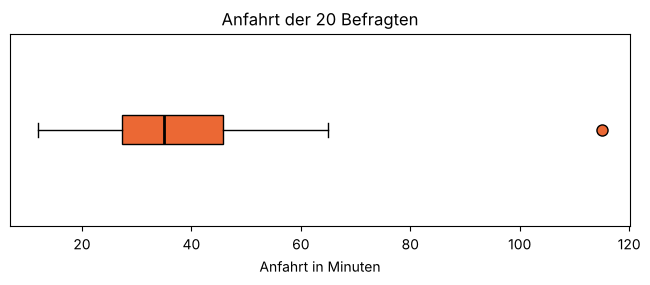

In [3]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.boxplot(anfahrt, orientation="horizontal", patch_artist=True,
           boxprops=dict(facecolor=ORANGE),
           medianprops=dict(color="black", linewidth=2),
           flierprops=dict(marker="o", markerfacecolor=ORANGE, markersize=8))
ax.set_title("Anfahrt der 20 Befragten")
ax.set_xlabel("Anfahrt in Minuten")
ax.set_yticks([])
plt.show()

<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Ein Bild aus fünf Zahlen. Gut, das lese sogar ich.“</td></tr></table>

---
## 2 – Welche Zahlen zeichnet Matplotlib?

`cbook.boxplot_stats(werte)` gibt genau die Zahlen zurück, die `ax.boxplot` zeichnet. Das Ergebnis ist eine Liste mit einem Wörterbuch pro Boxplot, deshalb `[0]`.

In [4]:
s = cbook.boxplot_stats(anfahrt)[0]
print("Q1:              ", s["q1"])                   # 27.25
print("Median:          ", s["med"])                  # 35.0
print("Q3:              ", s["q3"])                   # 45.75
print("Whisker unten:   ", s["whislo"])               # 12
print("Whisker oben:    ", s["whishi"])               # 65
print("Ausreißer:       ", s["fliers"].tolist())      # [115]

# Pandas liefert dieselben Quartile
print(anfahrt.quantile([0.25, 0.5, 0.75]).tolist())   # [27.25, 35.0, 45.75]

Q1:               27.25
Median:           35.0
Q3:               45.75
Whisker unten:    12
Whisker oben:     65
Ausreißer:        [115]
[27.25, 35.0, 45.75]


| | Skript (von Hand) | Matplotlib / Pandas |
|---|---|---|
| Q1 | 26,5 | 27,25 |
| Median | 35 | 35 |
| Q3 | 46,5 | 45,75 |
| Whisker | 12 und 65 | 12 und 65 |
| Ausreißer | 115 | 115 |

Die Box ist minimal schmaler. Das kennst du von Tag 3: Pandas und Matplotlib **interpolieren** zwischen zwei Werten, von Hand nimmt man die Mitte der unteren und oberen Hälfte. Whisker und Ausreißer sind gleich.

**Achtung bei Programmen** (Skript, Schritt 6): Matplotlib verwendet die 1,5-fache Zaun-Regel (`whis=1.5`). Manche Programme lassen die Whisker bis zum Minimum und Maximum laufen. In Matplotlib geht das mit `whis=(0, 100)`. Dann verschwindet der Ausreißer:

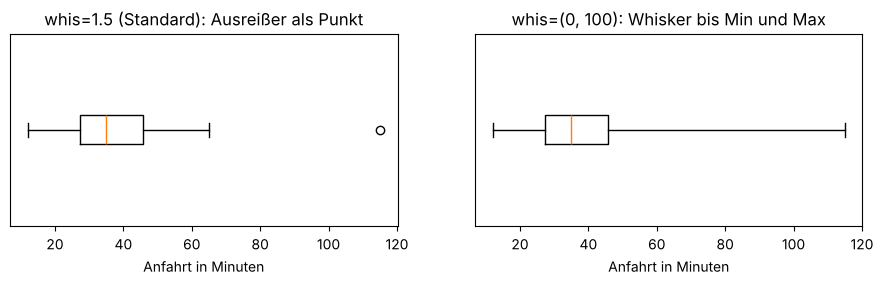

In [5]:
fig, (links, rechts) = plt.subplots(1, 2, figsize=(11, 2.5))

links.boxplot(anfahrt, orientation="horizontal")
links.set_title("whis=1.5 (Standard): Ausreißer als Punkt")

rechts.boxplot(anfahrt, orientation="horizontal", whis=(0, 100))
rechts.set_title("whis=(0, 100): Whisker bis Min und Max")

for ax in (links, rechts):
    ax.set_xlabel("Anfahrt in Minuten")
    ax.set_yticks([])
plt.show()

Rechts sieht die 115 aus wie ein ganz normaler Wert. Ein Blick in die Beschreibung lohnt sich also.

### Übung 1

Die Prüfungspunkte aus Übung 1 vom Vormittag:

In [6]:
punkte_ue = pd.Series([34, 45, 48, 52, 55, 58, 61, 63, 64, 66, 68, 70, 71, 73, 75, 78, 82, 85, 88, 95])

- **a)** Zeichne den Boxplot quer, mit Titel und Achsenbeschriftung.
- **b)** Lies mit `cbook.boxplot_stats` die fünf Zahlen, die Whisker und die Ausreißer aus. Vergleiche mit deiner Handlösung: 34 / 56,5 / 67 / 76,5 / 95.
- **c)** Berechne mit den Quartilen von Matplotlib den IQR und die Zäune. Gibt es Ausreißer?

In [7]:
# a)

In [8]:
# b)

In [9]:
# c)

# Block B – Raster und Gruppen

## 3 – Das Subplot-Raster

Bisher hattest du höchstens zwei oder drei Diagramme nebeneinander. `plt.subplots(zeilen, spalten)` baut ein ganzes Raster. Bei mehr als einer Zeile **und** mehr als einer Spalte ist `axes` eine Tabelle (ein NumPy-Array). Du greifst mit `axes[zeile, spalte]` auf ein Diagramm zu, gezählt ab 0.

(2, 3)


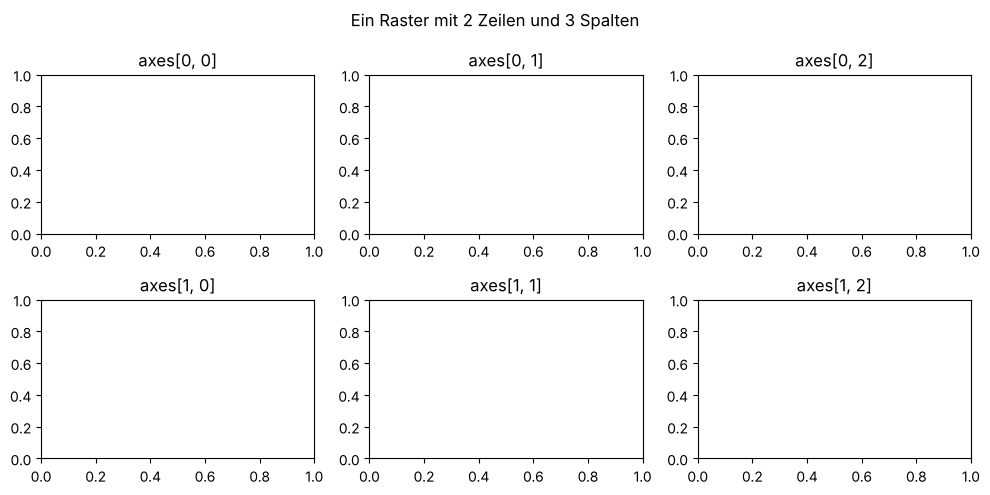

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
print(axes.shape)                                     # (2, 3): 2 Zeilen, 3 Spalten

for zeile in range(2):
    for spalte in range(3):
        axes[zeile, spalte].set_title(f"axes[{zeile}, {spalte}]")

fig.suptitle("Ein Raster mit 2 Zeilen und 3 Spalten")  # Titel über alles
fig.tight_layout()                                    # Abstände automatisch anpassen
plt.show()

| Befehl | Bedeutung |
|---|---|
| `fig, axes = plt.subplots(2, 3)` | Raster mit 2 Zeilen, 3 Spalten |
| `axes[0, 1]` | Zeile 0, Spalte 1 (oben Mitte) |
| `fig, (links, rechts) = plt.subplots(1, 2)` | bei nur einer Zeile: direkt auspacken |
| `axes.flatten()` | macht aus der Tabelle eine einfache Liste, praktisch für Schleifen |
| `sharex=True` / `sharey=True` | alle Diagramme teilen sich die x- bzw. y-Achse |
| `height_ratios=[3, 1]` / `width_ratios=[1, 2]` | Zeilen bzw. Spalten unterschiedlich groß |
| `fig.suptitle("...")` | Titel über dem ganzen Raster |
| `fig.tight_layout()` | verhindert, dass sich Beschriftungen überlappen |

> In älterem Material steht dafür `gridspec_kw={"height_ratios": [3, 1]}`. Seit Matplotlib 3.6 geht es direkt mit `height_ratios`.

---
## 4 – Histogramm und Boxplot übereinander
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Dann brauchen wir das Histogramm ja nicht mehr.“</td></tr></table>

Mit `sharex=True` teilen sich beide Diagramme die x-Achse. So stehen Histogramm und Boxplot genau übereinander.

[2, 11, 5, 1, 0, 1]


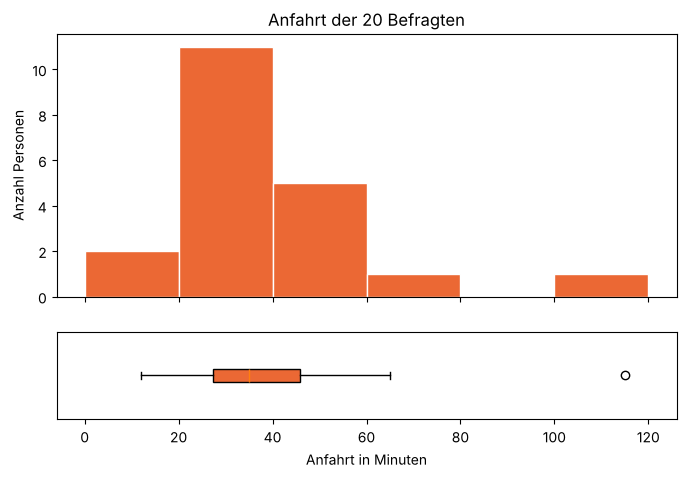

In [11]:
grenzen = list(range(0, 121, 20))
anzahl = pd.cut(anfahrt, bins=grenzen).value_counts().sort_index()     # wie im Skript: über a bis b
print(anzahl.values.tolist())                                          # [2, 11, 5, 1, 0, 1]

fig, (oben, unten) = plt.subplots(2, 1, sharex=True, figsize=(8, 5), height_ratios=[3, 1])

oben.bar(grenzen[:-1], anzahl.values, width=20, align="edge", color=ORANGE, edgecolor="white")
oben.set_title("Anfahrt der 20 Befragten")
oben.set_ylabel("Anzahl Personen")

unten.boxplot(anfahrt, orientation="horizontal", patch_artist=True, boxprops=dict(facecolor=ORANGE))
unten.set_yticks([])
unten.set_xlabel("Anfahrt in Minuten")

plt.show()

| | Histogramm | Boxplot |
|---|---|---|
| Lage, Streuung, Schiefe, Ausreißer | ✅ | ✅ |
| Median und Quartile direkt ablesen | – | ✅ |
| Gipfel und Lücken | ✅ | – |
| wie viele Werte dahinterstehen | ✅ | – |

**Schiefe im Boxplot.** Der Median sitzt nicht in der Mitte der Box, und der rechte Teil ist länger:

In [12]:
s = cbook.boxplot_stats(anfahrt)[0]
print("linker Teil der Box: ", s["med"] - s["q1"])     # 7.75
print("rechter Teil der Box:", s["q3"] - s["med"])     # 10.75
print("linker Whisker:      ", s["q1"] - s["whislo"])  # 15.25
print("rechter Whisker:     ", s["whishi"] - s["q3"])  # 19.25

linker Teil der Box:  7.75
rechter Teil der Box: 10.75
linker Whisker:       15.25
rechter Whisker:      19.25


Rechts ist alles länger: Die Anfahrt ist **rechtsschief**, wie das Histogramm gestern gezeigt hat.
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Also doch beide. Mein Aktenschrank wird immer voller.“</td></tr></table>

---
## 5 – Boxplots vergleichen
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Vormittags- und Abendkurs fahren ungefähr gleich lang zu uns.“</td></tr></table>

Boxplots sind zum Vergleichen gemacht. Du übergibst `ax.boxplot` eine **Liste** von Datenreihen und mit `tick_labels` die Namen dazu. (Vor Matplotlib 3.9 hieß der Parameter `labels`.)

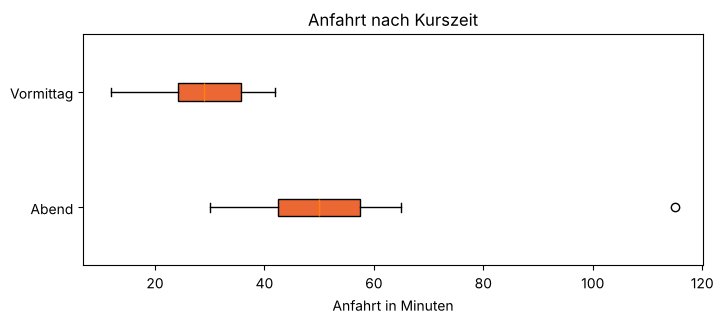

Vormittag  Median  29.0  Q1  24.25  Q3  35.75  IQR  11.5  Whisker 12–42  Ausreißer []
Abend      Median  50.0  Q1   42.5  Q3   57.5  IQR  15.0  Whisker 30–65  Ausreißer [115]


In [13]:
vormittag = umfrage.loc[umfrage["kurszeit"] == "Vormittag", "anfahrt_min"]
abend = umfrage.loc[umfrage["kurszeit"] == "Abend", "anfahrt_min"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot([vormittag, abend], tick_labels=["Vormittag", "Abend"], orientation="horizontal",
           patch_artist=True, boxprops=dict(facecolor=ORANGE))
ax.invert_yaxis()                                     # Vormittag oben
ax.set_title("Anfahrt nach Kurszeit")
ax.set_xlabel("Anfahrt in Minuten")
plt.show()

for name, werte in [("Vormittag", vormittag), ("Abend", abend)]:
    s = cbook.boxplot_stats(werte)[0]
    print(f"{name:<10} Median {s['med']:>5}  Q1 {s['q1']:>6}  Q3 {s['q3']:>6}  IQR {s['iqr']:>5}  "
          f"Whisker {s['whislo']}–{s['whishi']}  Ausreißer {s['fliers'].tolist()}")

- **Lage:** Median 29 Minuten gegen 50 Minuten. Die Box des Abendkurses beginnt erst dort, wo die des Vormittagskurses endet.
- **Streuung:** Der Abendkurs streut stärker (IQR 15 gegen 11,5; von Hand im Skript 20 gegen 13).
- **Ausreißer:** Nur der Abendkurs hat einen, die 115.

**Mit Pandas** geht es in einer Zeile. `by=` teilt nach einer Spalte auf:

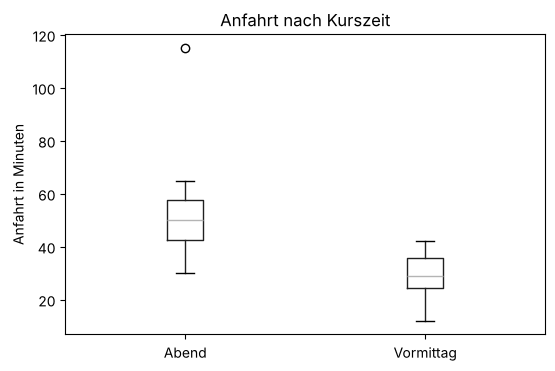

In [14]:
ax = umfrage.boxplot(column="anfahrt_min", by="kurszeit", figsize=(6, 4), grid=False)
ax.set_title("Anfahrt nach Kurszeit")
ax.figure.suptitle("")                                # Pandas setzt sonst einen zweiten Titel darüber
ax.set_xlabel("")
ax.set_ylabel("Anfahrt in Minuten")
plt.show()

<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„29 gegen 50 Minuten. ‚Ungefähr gleich‘ war wohl etwas großzügig.“</td></tr></table>

### Übung 2

Nimm die beiden Boxplots aus Abschnitt 5 (Übung 2 vom Vormittag). Beantworte die Fragen mit Code.

- **a)** Wie groß ist der Median im Abendkurs?
- **b)** In welchem Kurs streuen die Werte stärker? Woran erkennst du das?
- **c)** Stimmt die Aussage „Ein Viertel des Vormittagskurses braucht höchstens 23,5 Minuten“? Vergleiche Q1 von Matplotlib mit der Handlösung (23,5). Zähle dann direkt nach.
- **d)** Wie lang ist der längste Weg im Vormittagskurs?

In [15]:
# a)

In [16]:
# b)

In [17]:
# c)

In [18]:
# d)

# Block C – Das Streudiagramm

## 6 – Lernstunden und Punkte
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Lernen bringt nichts. Entweder man kann es oder man kann es nicht.“</td></tr></table>

Jede Person wird zu einem Punkt: waagerecht ihre Lernstunden, senkrecht ihre Punkte. `ax.scatter(x, y)` zeichnet die Punkte.

Das Merkmal, das etwas **erklären** soll (unabhängige Variable), kommt auf die **x-Achse**. Das Merkmal, das erklärt werden soll (abhängige Variable), kommt auf die **y-Achse**.
<table><tr><td width="160"><img src="png%20Dateien/nils_eichhoernchen.png" alt="Nils" width="150"></td><td><b>Nils sagt:</b><br><br>„Zwei Messwerte pro Person, zwei Achsen. Ich zähle nichts, ich trage nur ein.“</td></tr></table>

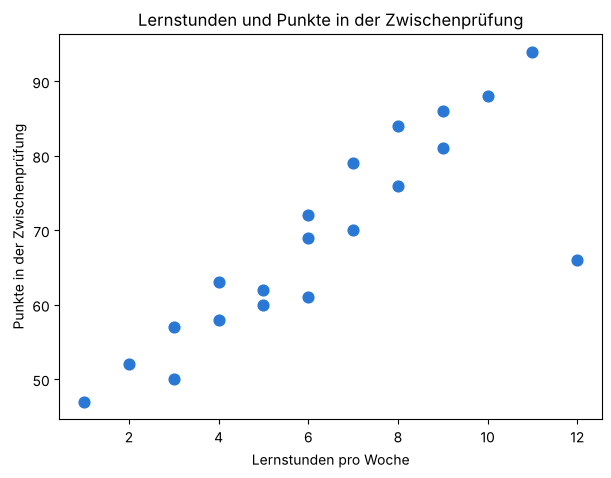

Person 103: 4 Stunden, 63 Punkte


In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(umfrage["lernstunden"], umfrage["punkte"], color=BLAU, s=60)
ax.set_title("Lernstunden und Punkte in der Zwischenprüfung")
ax.set_xlabel("Lernstunden pro Woche")                # unabhängige Variable
ax.set_ylabel("Punkte in der Zwischenprüfung")        # abhängige Variable
plt.show()

p103 = umfrage[umfrage["teilnehmer_id"] == 103].iloc[0]
print("Person 103:", p103["lernstunden"], "Stunden,", p103["punkte"], "Punkte")   # 4 und 63

| Parameter | Bedeutung | Beispiel |
|---|---|---|
| `s` | Punktgröße | `s=60` |
| `color` | Farbe | `color=BLAU` |
| `alpha` | Transparenz von 0 bis 1, hilft bei überlappenden Punkten | `alpha=0.7` |
| `marker` | Form | `"o"`, `"s"`, `"^"` |

**Lesen:**

- **Richtung:** Je mehr Stunden, desto mehr Punkte. Ein **positiver** Zusammenhang.
- **Form:** Die Punkte folgen ungefähr einer Geraden. Der Zusammenhang ist **linear**.
- **Stärke:** Die Punkte liegen eng an der gedachten Geraden: **stark**.
- **Ausreißer:** Eine Person lernt 12 Stunden und hat nur 66 Punkte.

Den Ausreißer heben wir hervor: Wir zeichnen ihn ein zweites Mal in Orange und beschriften ihn mit `ax.annotate`.

12 66


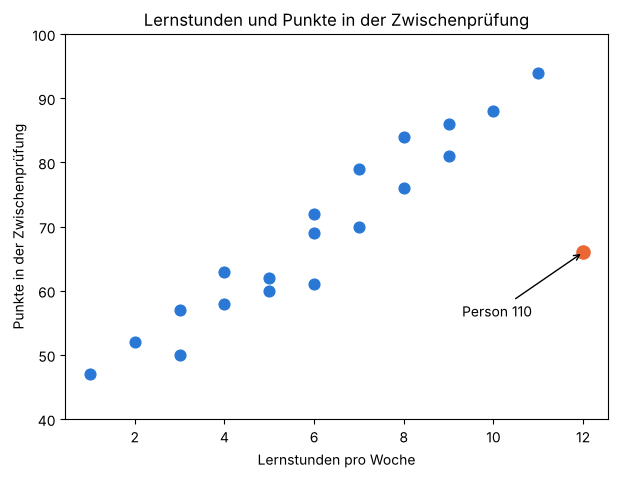

In [20]:
p110 = umfrage[umfrage["teilnehmer_id"] == 110].iloc[0]
print(p110["lernstunden"], p110["punkte"])            # 12 66

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(umfrage["lernstunden"], umfrage["punkte"], color=BLAU, s=60)
ax.scatter(p110["lernstunden"], p110["punkte"], color=ORANGE, s=90)
ax.annotate("Person 110", xy=(p110["lernstunden"], p110["punkte"]), xytext=(9.3, 56),
            arrowprops=dict(arrowstyle="->"))
ax.set_ylim(40, 100)                                  # darf hier bei 40 beginnen
ax.set_title("Lernstunden und Punkte in der Zwischenprüfung")
ax.set_xlabel("Lernstunden pro Woche")
ax.set_ylabel("Punkte in der Zwischenprüfung")
plt.show()

<table><tr><td width="160"><img src="png%20Dateien/der_ausreisser.png" alt="Der Ausreißer" width="150"></td><td><b>Der Ausreißer meldet sich:</b><br><br>„Ja, das bin schon wieder ich. Ich lerne viel, nur eben nicht für die Prüfung.“</td></tr></table>

**Die Achsen müssen nicht bei null beginnen.** Beim Balkendiagramm vergleicht das Auge Längen, hier vergleicht es Lagen. Die Punkte-Achse darf bei 40 beginnen, solange sie beschriftet ist.
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Gut, Lernen scheint doch etwas zu bringen. Zumindest bei den meisten.“</td></tr></table>

---
## 7 – Muster im Streudiagramm
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Wer weit fährt, ist motivierter und schreibt bessere Prüfungen.“</td></tr></table>

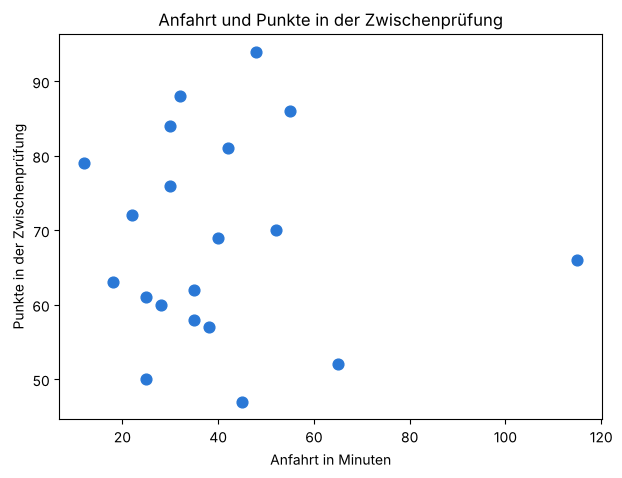

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(umfrage["anfahrt_min"], umfrage["punkte"], color=BLAU, s=60)
ax.set_title("Anfahrt und Punkte in der Zwischenprüfung")
ax.set_xlabel("Anfahrt in Minuten")
ax.set_ylabel("Punkte in der Zwischenprüfung")
plt.show()

Eine **Wolke ohne Richtung**: Ob jemand 20 oder 50 Minuten fährt, die Punkte liegen mal hoch, mal tief. Auch Person 110 mit ihren 115 Minuten liegt mit 66 Punkten mitten im Feld.
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Keine Richtung. Schade um die schöne Geschichte von der Motivation.“</td></tr></table>

**Die vier Grundmuster** mit erfundenen Daten im 2×2-Raster. `axes.flatten()` macht aus dem Raster eine Liste, damit die Schleife einfach bleibt.

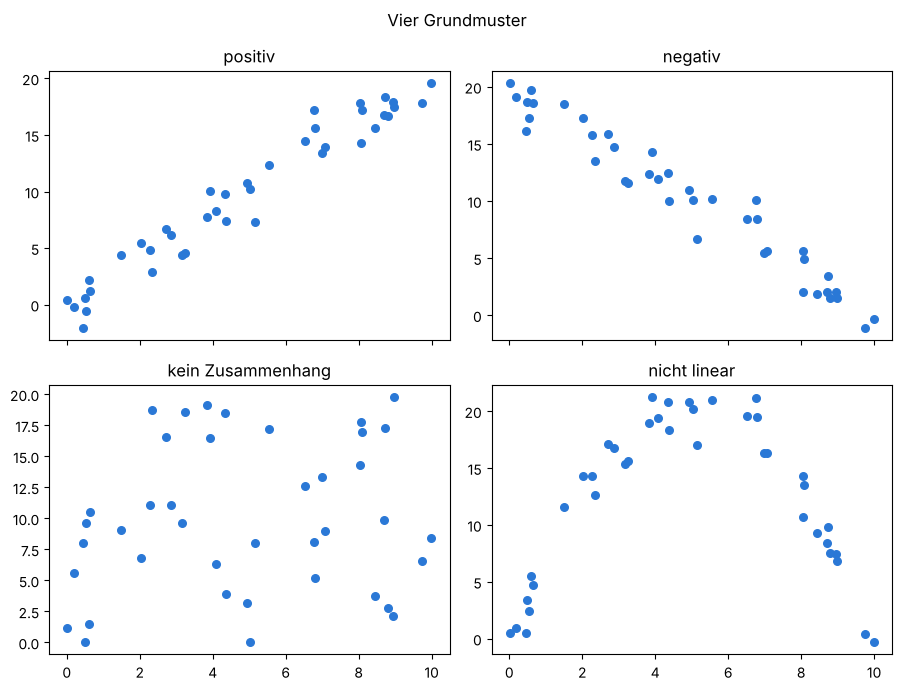

In [22]:
rng = np.random.default_rng(5)                        # Zufallsgenerator mit festem Startwert
x = rng.uniform(0, 10, 40)                            # 40 Werte zwischen 0 und 10
rauschen = rng.normal(0, 1.5, 40)

muster = {
    "positiv": 2 * x + rauschen,
    "negativ": 20 - 2 * x + rauschen,
    "kein Zusammenhang": rng.uniform(0, 20, 40),
    "nicht linear": 20 - 0.8 * (x - 5) ** 2 + rauschen,   # z. B. Nervosität und Leistung
}

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True)
for ax, (titel, y) in zip(axes.flatten(), muster.items()):
    ax.scatter(x, y, color=BLAU, s=30)
    ax.set_title(titel)
fig.suptitle("Vier Grundmuster")
fig.tight_layout()
plt.show()

- **Positiv:** Steigt das eine, steigt meist auch das andere.
- **Negativ:** Steigt das eine, sinkt meist das andere, zum Beispiel Übungsstunden und Tippfehler.
- **Kein Zusammenhang:** eine Wolke ohne Richtung.
- **Nicht linear:** Es gibt einen Zusammenhang, aber keine Gerade. Zu wenig und zu viel Nervosität schaden beide.

> **Ein Muster ist kein Beweis.** Steigen zwei Merkmale gemeinsam, heißt das noch nicht, dass das eine das andere verursacht. Darum geht es morgen.

### Übung 3

Acht Teilnehmende haben Zehnfingerschreiben geübt (Übung 5 vom Vormittag):

In [23]:
stunden = [1, 2, 3, 4, 5, 6, 7, 8]
fehler = [24, 20, 21, 15, 12, 13, 8, 6]

- **a)** Zeichne das Streudiagramm. Überlege zuerst: Welches Merkmal kommt auf die x-Achse?
- **b)** Beschreibe Richtung, Form und Stärke als Kommentar.

In [24]:
# a)

In [25]:
# b)

# Block D – Liniendiagramm und Diagramm-Tricks

## 8 – Das Liniendiagramm

Für Entwicklungen über die Zeit verbindet man die Werte mit einer Linie: `ax.plot(x, y)`. Die Akademie hat ihre Anmeldungen über 24 Monate gezählt, dazu den Kaffeeverbrauch in Litern.

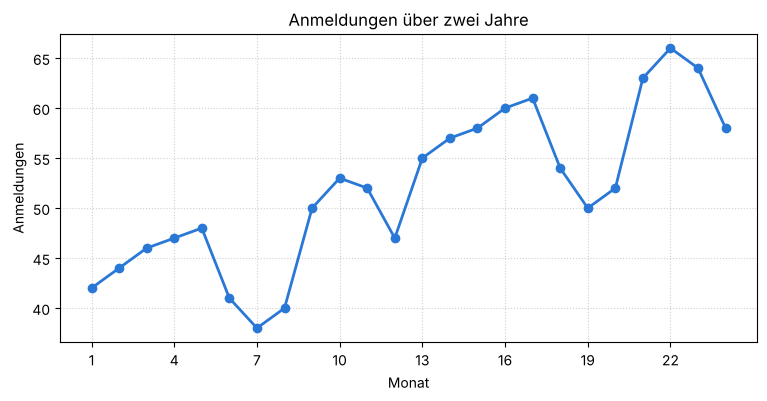

In [26]:
monate = list(range(1, 25))                           # Monat 1 = Januar im ersten Jahr
anmeldungen = [42, 44, 46, 47, 48, 41, 38, 40, 50, 53, 52, 47, 55, 57, 58, 60, 61, 54, 50, 52, 63, 66, 64, 58]
kaffee = [310, 318, 325, 330, 333, 296, 280, 290, 345, 362, 357, 330, 370, 381, 386, 395, 400, 362, 340, 352, 410, 425, 415, 380]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monate, anmeldungen, color=BLAU, linewidth=2, marker="o")
ax.set_xticks(range(1, 25, 3))
ax.set_title("Anmeldungen über zwei Jahre")
ax.set_xlabel("Monat")
ax.set_ylabel("Anmeldungen")
ax.grid(True, linestyle=":", alpha=0.6)
plt.show()

| Parameter | Bedeutung | Beispiel |
|---|---|---|
| `color` | Linienfarbe | `color=BLAU` |
| `linewidth` / `lw` | Linienstärke | `lw=2` |
| `linestyle` / `ls` | Linienstil | `"-"`, `"--"`, `":"` |
| `marker` | Symbol an jedem Datenpunkt | `"o"`, `"s"` |
| `label` | Name für die Legende | `label="Anmeldungen"` |

Über zwei Jahre steigen die Anmeldungen. Im Sommer (Monat 6 bis 8 und 18 bis 20) und zum Jahresende gehen sie jedes Jahr etwas zurück.

---
## 9 – Diagramm-Tricks nachbauen und reparieren
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Ich habe für die Geschäftsführung ein paar Diagramme gebaut. Alle Zahlen stimmen, ganz ehrlich.“</td></tr></table>

Die Zahlen stimmen tatsächlich. Trick 1, die abgeschnittene Achse, kennst du aus Notebook 4 (Abschnitt 7). Trick 2, Fläche statt Länge, ist im Skript eine Zeichnung: Doppelt so hoch **und** doppelt so breit ergibt die vierfache Fläche. Die Tricks 3 bis 5 bauen wir nach.

**Trick 3 – Der passende Ausschnitt.** „Die Anmeldungen brechen ein!“ Mit `width_ratios` bekommt das ehrliche Diagramm mehr Platz.

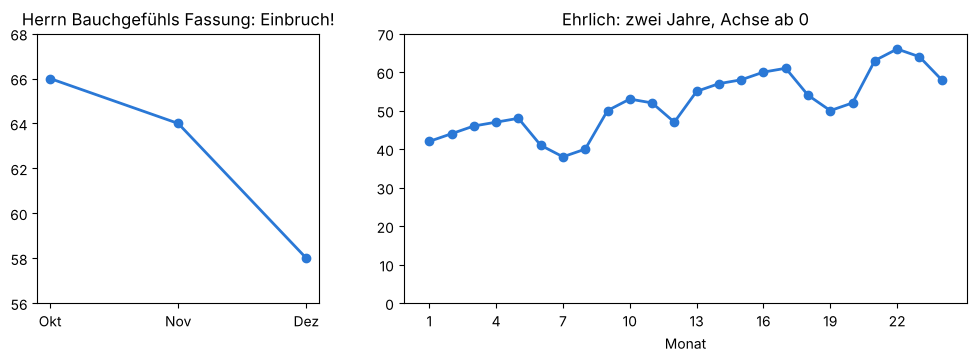

[66, 64, 58]


In [27]:
fig, (falsch, ehrlich) = plt.subplots(1, 2, figsize=(12, 3.5), width_ratios=[1, 2])

falsch.plot(["Okt", "Nov", "Dez"], anmeldungen[-3:], color=BLAU, linewidth=2, marker="o")
falsch.set_ylim(56, 68)
falsch.set_title("Herrn Bauchgefühls Fassung: Einbruch!")

ehrlich.plot(monate, anmeldungen, color=BLAU, linewidth=2, marker="o")
ehrlich.set_ylim(0, 70)
ehrlich.set_xticks(range(1, 25, 3))
ehrlich.set_title("Ehrlich: zwei Jahre, Achse ab 0")
ehrlich.set_xlabel("Monat")

plt.show()
print(anmeldungen[-3:])                               # [66, 64, 58]

Links fällt die Linie steil ab: nur drei Monate und eine Achse ab 56. Rechts sieht man: Zum Jahresende sinken die Anmeldungen jedes Jahr, insgesamt steigen sie.

**Trick 4 – Ungleiche Abstände.** Gibt man Jahre als **Text** an, setzt Matplotlib sie wie Kategorien in gleichen Abständen. Als **Zahlen** bekommen sie ihre echten Abstände.

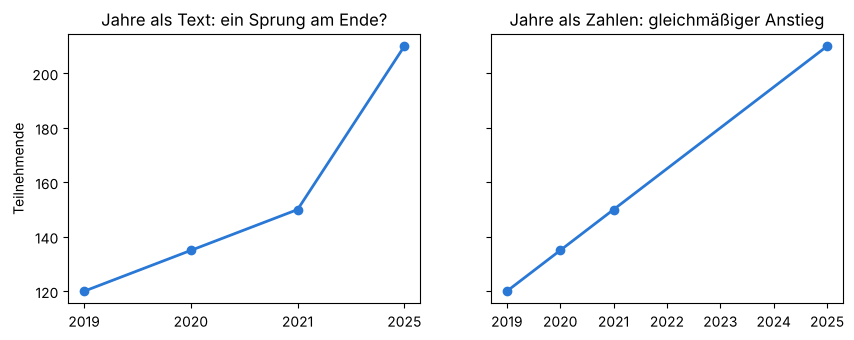

15.0 15.0


In [28]:
jahre = [2019, 2020, 2021, 2025]
teilnehmende = [120, 135, 150, 210]

fig, (falsch, ehrlich) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

falsch.plot([str(j) for j in jahre], teilnehmende, color=BLAU, linewidth=2, marker="o")   # Text
falsch.set_title("Jahre als Text: ein Sprung am Ende?")

ehrlich.plot(jahre, teilnehmende, color=BLAU, linewidth=2, marker="o")                    # Zahlen
ehrlich.set_xticks(range(2019, 2026))
ehrlich.set_title("Jahre als Zahlen: gleichmäßiger Anstieg")

falsch.set_ylabel("Teilnehmende")
plt.show()

# Anstieg pro Jahr
print((150 - 120) / 2, (210 - 150) / 4)               # 15.0 15.0

Zwischen 2021 und 2025 liegen vier Jahre, links haben sie so viel Platz wie ein einziges. Rechts sieht man: Es sind jedes Jahr 15 Teilnehmende mehr.

**Trick 5 – Zwei y-Achsen.** `ax.twinx()` erzeugt eine zweite y-Achse rechts. Mit passend gewählten Grenzen liegt jede Kurve über jeder anderen.

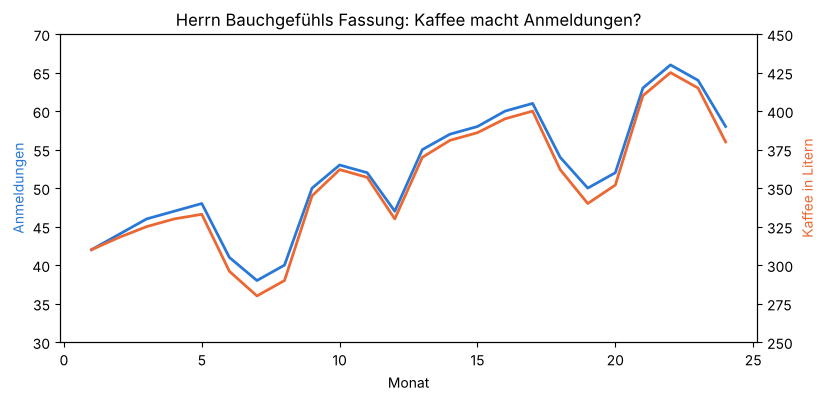

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monate, anmeldungen, color=BLAU, linewidth=2, label="Anmeldungen")
ax.set_ylabel("Anmeldungen", color=BLAU)
ax.set_ylim(30, 70)

ax2 = ax.twinx()                                      # zweite y-Achse, rechts
ax2.plot(monate, kaffee, color=ORANGE, linewidth=2, label="Kaffee")
ax2.set_ylabel("Kaffee in Litern", color=ORANGE)
ax2.set_ylim(250, 450)                                # so gewählt, dass die Linien übereinanderliegen

ax.set_title("Herrn Bauchgefühls Fassung: Kaffee macht Anmeldungen?")
ax.set_xlabel("Monat")
plt.show()

Beide Linien steigen und fallen gemeinsam. Das liegt an etwas Drittem: Wenn mehr Leute in der Akademie sind, wird mehr Kaffee getrunken. Ehrlich wären zwei getrennte Diagramme. Das baust du in Übung 13.

> `twinx()` kennen ist gut. Benutzen solltest du es nur, wenn du genau weißt, was du tust.

---
## 10 – Die Checkliste

| Frage | Worauf du in Matplotlib achtest |
|---|---|
| Beginnt die Achse eines Balkendiagramms bei null? | kein `set_ylim` mit unterer Grenze über 0 |
| Sind die Abstände auf der Achse gleichmäßig? | Jahre und Zeiten als Zahlen übergeben, nicht als Text |
| Werden Längen verglichen oder Flächen? | Balken statt verschieden großer Symbole |
| Welcher Zeitraum wird gezeigt, was fehlt davor oder danach? | ganze Reihe zeigen, nicht nur `[-3:]` |
| Gibt es zwei y-Achsen? | `twinx()` vermeiden, lieber zwei Diagramme |
| Sind Achsen und Einheiten beschriftet, gibt es eine Quelle? | `set_xlabel`, `set_ylabel`, `set_title` |
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Fünf Tricks, und ihr kennt sie alle. Dann muss ich der Geschäftsführung wohl die ehrlichen Fassungen zeigen.“</td></tr></table>

### Übung 4

Herrn Bauchgefühls Rekord (Übung 8 vom Vormittag). 2019 waren es 52 Teilnehmende, 2020 waren es 55, 2022 waren es 61 und 2026 sind es 68.

In [30]:
rekord_jahre = [2019, 2020, 2022, 2026]
rekord_tn = [52, 55, 61, 68]

- **a)** Baue sein Diagramm nach: Liniendiagramm mit Punkten, Jahre als Text, y-Achse von 50 bis 70.
- **b)** Welche zwei Tricks findest du? Schreibe sie als Kommentar.
- **c)** Baue die ehrliche Fassung: Jahre als Zahlen, y-Achse ab 0.
- **d)** Um wie viel Prozent ist die Akademie von 2019 bis 2026 tatsächlich gewachsen?

In [31]:
# a)

In [32]:
# b)

In [33]:
# c)

In [34]:
# d)

# Block E – Welches Diagramm wann?

## 11 – Übersicht über beide Diagramm-Tage

| Frage | Merkmal | Diagramm | Matplotlib |
|---|---|---|---|
| Wie oft kommt jede Sorte vor? | ein qualitatives | Balkendiagramm | `ax.bar` / `ax.barh` |
| Wie verteilen sich die Werte? | ein quantitatives | Histogramm | `ax.hist` |
| Wo liegen Mitte, Streuung und Ausreißer? Wie unterscheiden sich Gruppen? | ein quantitatives, evtl. nach Gruppen | Boxplot | `ax.boxplot` |
| Hängen zwei Merkmale zusammen? | zwei quantitative | Streudiagramm | `ax.scatter` |
| Wie verteilen sich Anteile in mehreren Gruppen? | zwei qualitative | gestapelte Balken | `anteile.plot.barh(stacked=True)` |
| Wie entwickelt sich etwas über die Zeit? | ein quantitatives über die Zeit | Liniendiagramm mit gleichmäßiger Zeitachse | `ax.plot` |

---
## 12 – Ein Dashboard

Ein Raster eignet sich für eine Übersicht auf einen Blick. Jedes Diagramm im Raster ist ein eigenes `Axes`, also gelten alle Befehle wie gewohnt.

Pandas zeichnet mit `ax=...` in ein vorhandenes Diagramm des Rasters, statt eine neue Figure anzulegen.

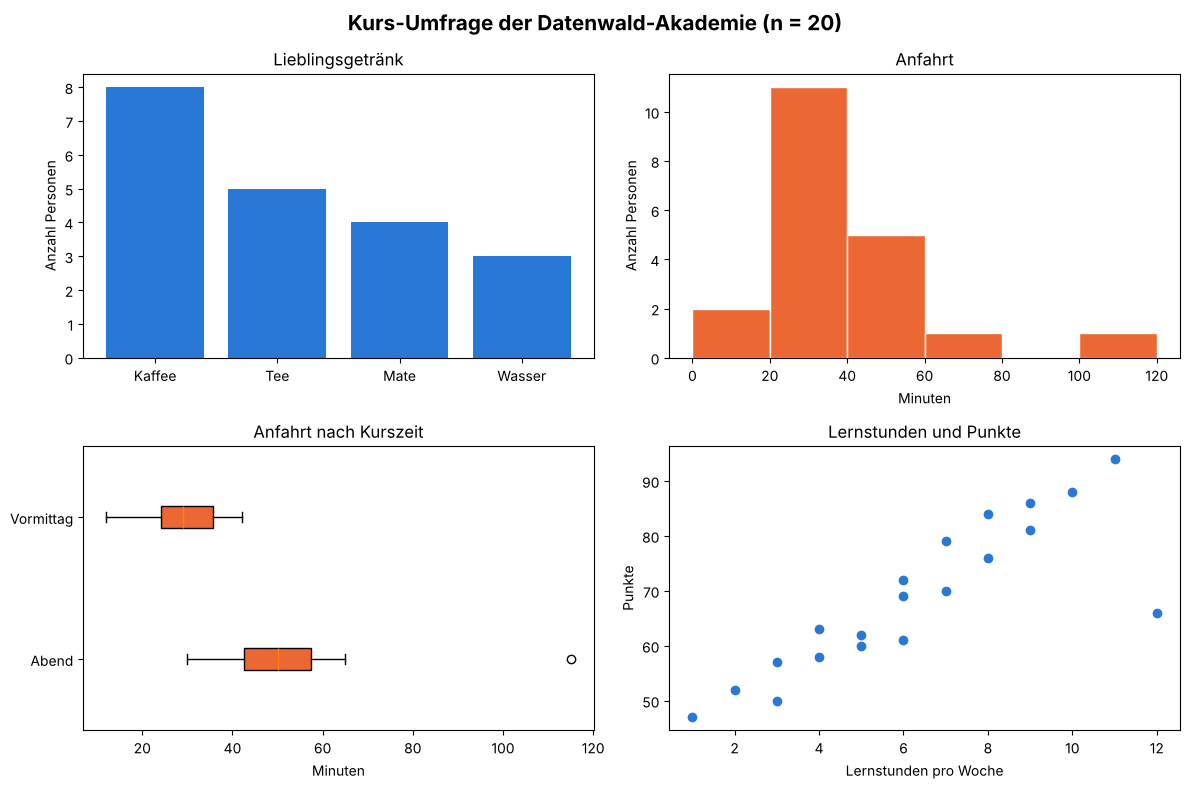

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# oben links: Balkendiagramm
anzahl_g = umfrage["getraenk"].value_counts()
axes[0, 0].bar(anzahl_g.index, anzahl_g.values, color=BLAU)
axes[0, 0].set_title("Lieblingsgetränk")
axes[0, 0].set_ylabel("Anzahl Personen")

# oben rechts: Histogramm
axes[0, 1].bar(grenzen[:-1], anzahl.values, width=20, align="edge", color=ORANGE, edgecolor="white")
axes[0, 1].set_xticks(grenzen)
axes[0, 1].set_title("Anfahrt")
axes[0, 1].set_xlabel("Minuten")
axes[0, 1].set_ylabel("Anzahl Personen")

# unten links: Boxplots nach Gruppe
axes[1, 0].boxplot([vormittag, abend], tick_labels=["Vormittag", "Abend"], orientation="horizontal",
                   patch_artist=True, boxprops=dict(facecolor=ORANGE))
axes[1, 0].invert_yaxis()
axes[1, 0].set_title("Anfahrt nach Kurszeit")
axes[1, 0].set_xlabel("Minuten")

# unten rechts: Streudiagramm
axes[1, 1].scatter(umfrage["lernstunden"], umfrage["punkte"], color=BLAU)
axes[1, 1].set_title("Lernstunden und Punkte")
axes[1, 1].set_xlabel("Lernstunden pro Woche")
axes[1, 1].set_ylabel("Punkte")

fig.suptitle("Kurs-Umfrage der Datenwald-Akademie (n = 20)", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig("kurs_dashboard.png", dpi=150, bbox_inches="tight")   # erst speichern …
plt.show()                                                          # … dann anzeigen

### Übung 5

Übung 10 vom Vormittag, diesmal mit Code.

- **a)** Ordne jeder Situation ein Diagramm zu (als Kommentar): Lieblingsfarben im Kurs · Verteilung der Körpergrößen · Anfahrt in drei Kursen vergleichen · Zusammenhang zwischen Schlafdauer und Konzentration · Anmeldungen der letzten 24 Monate · Anteil der Kaffeetrinker im Vormittags- und im Abendkurs.
- **b)** Drei dieser Situationen kannst du mit unseren Daten zeichnen. Baue ein Raster mit 1 Zeile und 3 Spalten:
  - links: Anteil der Kaffeetrinker im Vormittags- und im Abendkurs. Tipp: `pd.crosstab(umfrage["kurszeit"], umfrage["getraenk"] == "Kaffee", normalize="index")`, dann `.plot.barh(stacked=True, ax=links)`.
  - Mitte: die Punkte in der Zwischenprüfung nach Kurszeit.
  - rechts: die Anmeldungen der letzten 24 Monate.
- **c)** Gib dem Raster einen Gesamttitel und speichere es als `mein_dashboard.png`.

In [36]:
# a)

In [37]:
# b, c)

# Block F – Weitere Übungen

| Übung | zu Block | Thema |
|---|---|---|
| 6 | A | Wartezeiten: Wo endet der Whisker? |
| 7 | A und B | UK-Charts 1964: Wochen in den Charts als Boxplot |
| 8 | B | Dreispaltiges Layout |
| 9 | C | Abwesenheiten und Prüfungsergebnis |
| 10 | C | Alter und Tippgeschwindigkeit |
| 11 | C | UK-Charts 1964: Höchste Platzierung und Wochen in den Charts |
| 12 | D | Gehaltsentwicklung |
| 13 | D | Trick 5 ehrlich gemacht |

---
### Übung 6 (zu Block A)

Neun Wartezeiten in Minuten (Übung 3 vom Vormittag): 3, 5, 6, 8, 9, 11, 12, 15, 30.

- **a)** Zeichne den Boxplot quer.
- **b)** Lies Q1, Median, Q3, die Whisker und die Ausreißer aus. Wo enden die Whisker?
- **c)** Vergleiche mit deiner Handrechnung. Was ist anders, was gleich?

In [38]:
# a)

In [39]:
# b)

In [40]:
# c)

---
### Übung 7 (zu Block A und B)

Die britischen Single-Charts vom Januar 1964. `WoC` ist die Anzahl der Wochen in den Charts.

In [41]:
ordner = "csv & excel Dateien/"
charts = pd.read_csv(ordner + "UK-top40-1964-1-2.tsv", sep="\t")
woc = charts["WoC"]
charts.head()

,Pos,LW,Title,Artist,Publisher,Peak Pos,WoC
0,1,1,I WANT TO HOLD YOUR HAND,THE BEATLES,PARLOPHONE,1,5
1,2,6,GLAD ALL OVER,THE DAVE CLARK FIVE,COLUMBIA,2,7
2,3,2,SHE LOVES YOU,THE BEATLES,PARLOPHONE,1,19
3,4,3,YOU WERE MADE FOR ME,FREDDIE AND THE DREAMERS,COLUMBIA,3,9
4,5,9,TWENTY FOUR HOURS FROM TULSA,GENE PITNEY,UNITED ARTISTS,5,5


- **a)** Zeichne Histogramm (Klassenbreite 2, Grenzen auf halben Werten wie in Notebook 4) und Boxplot übereinander mit gemeinsamer x-Achse.
- **b)** Lies die fünf Zahlen, die Whisker und die Ausreißer aus.
- **c)** Welcher Titel ist der Ausreißer? Suche ihn mit den Werten aus `fliers` in der Tabelle.
- **d)** Welche Form hat die Verteilung? Woran erkennst du sie im Boxplot?

In [42]:
# a)

In [43]:
# b)

In [44]:
# c)

In [45]:
# d)

---
### Übung 8 (zu Block B)

Erstelle eine Figure mit **1 Zeile und 3 Spalten** (`figsize=(12, 4)`):

- **a)** links ein Liniendiagramm von `y = x²` für `x` von 0 bis 10 (Tipp: `np.linspace(0, 10, 100)`)
- **b)** in der Mitte ein Balkendiagramm der Kategorien `["A", "B", "C", "D"]` mit den Werten `[4, 7, 3, 8]`
- **c)** rechts ein Histogramm von 100 normalverteilten Zufallswerten (`np.random.seed(1)`, `np.random.normal(0, 1, 100)`)

Alle drei bekommen einen Titel.

In [46]:
# a, b, c)

---
### Übung 9 (zu Block C)

Abwesenheiten und Prüfungsergebnis von zehn Teilnehmenden:

In [47]:
abwesenheiten = [0, 1, 2, 3, 4, 5, 6, 8, 10, 12]
ergebnis = [88, 85, 82, 78, 74, 70, 65, 55, 45, 38]

- **a)** Zeichne ein Streudiagramm mit roten Punkten (`color="firebrick"`), Titel und Achsenbeschriftungen. Welches Merkmal kommt auf die x-Achse?
- **b)** Beschreibe Richtung, Form und Stärke.

In [48]:
# a)

In [49]:
# b)

---
### Übung 10 (zu Block C)

Ein simulierter Datensatz aus einer Firmenbefragung (n = 80): Hängt die Tippgeschwindigkeit vom Alter ab?

In [50]:
np.random.seed(15)
alter = np.random.randint(22, 62, size=80)
tipp_basis = 80 - (alter - 22) * 0.6
tippgeschwindigkeit = tipp_basis + np.random.randn(80) * 12

- **a)** Zeichne ein Streudiagramm: Punkte in `"coral"`, Größe `s=50`, Transparenz `alpha=0.7`. Titel: „Alter vs. Tippgeschwindigkeit (n=80)“.
- **b)** Zeichne eine gestrichelte waagerechte Linie beim Mittelwert der Tippgeschwindigkeit ein (`ax.axhline`), mit Legende.
- **c)** Beschreibe Richtung und Stärke. Warum hilft hier `alpha`?

In [51]:
# a, b)

In [52]:
# c)

---
### Übung 11 (zu Block C)

Hängen die Wochen in den Charts (`WoC`) mit der höchsten erreichten Platzierung (`Peak Pos`) zusammen?

- **a)** Zeichne das Streudiagramm: `WoC` auf der x-Achse, `Peak Pos` auf der y-Achse.
- **b)** Beschreibe die Richtung. Aber Vorsicht: Ist Platz 1 eine „große“ oder eine „kleine“ Platzierung?
- **c)** Drehe die y-Achse mit `ax.invert_yaxis()` um, sodass Platz 1 oben steht. Wie sieht das Muster jetzt aus? Was heißt es inhaltlich?
- **d)** Markiere den Titel mit den meisten Wochen mit `ax.annotate`.

In [53]:
# a)

In [54]:
# b)

In [55]:
# c, d)

---
### Übung 12 (zu Block D)

Das durchschnittliche Jahresgehalt von Datenanalysten in Deutschland nach Berufsjahren:

In [56]:
berufsjahre = [0, 2, 4, 6, 8, 10, 12, 15]
gehalt = [36000, 42000, 50000, 58000, 65000, 72000, 78000, 85000]

- **a)** Zeichne ein Liniendiagramm: gestrichelt (`"--"`), Farbe `"steelblue"`, `lw=2`, Datenpunkte mit `marker="o"`, Gitter. Titel: „Gehaltsentwicklung: Datenanalyst/in in Deutschland“.
- **b)** Formatiere die y-Achse als „36k“, „42k“ … Tipp: `ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda wert, _: f"{wert/1000:.0f}k"))`.
- **c)** Zeichne die Linie noch einmal mit den Berufsjahren als **Text** (`[str(j) for j in berufsjahre]`). Was passiert zwischen 12 und 15? Welcher Trick ist das?

In [57]:
# a, b)

In [58]:
# c)

---
### Übung 13 (zu Block D)

Trick 5 aus Abschnitt 9 ehrlich gemacht.

- **a)** Zeichne Anmeldungen und Kaffee in **zwei Diagrammen untereinander** mit gemeinsamer x-Achse, jedes mit eigener Beschriftung.
- **b)** Berechne den Kaffee pro Anmeldung für jeden Monat. Was fällt auf? Was heißt das für Herrn Bauchgefühls Diagramm?

In [59]:
# a)

In [60]:
# b)

---
## 13 – Zusammenfassung

| Aufgabe | Befehl |
|---|---|
| Boxplot quer | `ax.boxplot(werte, orientation="horizontal")` |
| Boxplot gestalten | `patch_artist=True, boxprops=dict(facecolor=...), medianprops=dict(...)` |
| Zahlen des Boxplots auslesen | `cbook.boxplot_stats(werte)[0]` → `q1`, `med`, `q3`, `whislo`, `whishi`, `fliers` |
| Whisker bis Min/Max (Vorsicht!) | `whis=(0, 100)` |
| Boxplots vergleichen | `ax.boxplot([reihe1, reihe2], tick_labels=[...])` |
| Boxplots mit Pandas | `df.boxplot(column="...", by="...")` |
| Raster | `fig, axes = plt.subplots(2, 2)`, dann `axes[zeile, spalte]` |
| Raster in Schleife | `for ax in axes.flatten():` |
| gemeinsame Achse | `sharex=True` / `sharey=True` |
| unterschiedliche Größen | `height_ratios=[3, 1]` / `width_ratios=[1, 2]` |
| Titel über alles, Abstände | `fig.suptitle("...")`, `fig.tight_layout()` |
| Pandas in ein Raster zeichnen | `df.plot.barh(..., ax=axes[0, 1])` |
| Streudiagramm | `ax.scatter(x, y, s=..., alpha=...)` (unabhängige Variable auf x) |
| Punkt beschriften | `ax.annotate(text, xy=..., xytext=..., arrowprops=dict(arrowstyle="->"))` |
| Liniendiagramm | `ax.plot(x, y, marker="o", linestyle="--")` |
| Zeitachse ehrlich | Jahre als Zahlen, nicht als Text |
| zweite y-Achse (nur mit Bedacht) | `ax2 = ax.twinx()` |
| waagerechte Linie | `ax.axhline(y, ...)` |
| Achse umdrehen | `ax.invert_yaxis()` |
| y-Achse formatieren | `ax.yaxis.set_major_formatter(plt.FuncFormatter(...))` |
| speichern (vor `plt.show()`!) | `fig.savefig("datei.png", dpi=150, bbox_inches="tight")` |

---
*Material erstellt von Julia Brutskaya | FIDP Daten- und Prozessanalyse*